In [1]:
!pip install -q transformers datasets accelerate sentencepiece

In [2]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ GPU not detected. Go to Runtime → Change runtime type → T4 GPU")

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [3]:
from datasets import load_dataset

pope = load_dataset("MM-Hallu/POPE")

print(pope)

README.md:   0%|          | 0.00/524 [00:00<?, ?B/s]

data/test-00000-of-00003.parquet: reconstructing file:   0%|          |  0.00B / 85.0MB            

data/test-00000-of-00003.parquet: downloading bytes:           |  0.00B            

data/test-00001-of-00003.parquet: reconstructing file:   0%|          |  0.00B / 85.0MB            

data/test-00001-of-00003.parquet: downloading bytes:           |  0.00B            

data/test-00002-of-00003.parquet: reconstructing file:   0%|          |  0.00B / 85.0MB            

data/test-00002-of-00003.parquet: downloading bytes:           |  0.00B            

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    test: Dataset({
        features: ['id', 'question_id', 'question', 'answer', 'image_source', 'image', 'category'],
        num_rows: 9000
    })
})


In [4]:
print(pope.keys())

for split in pope.keys():
    print(split, len(pope[split]))

dict_keys(['test'])
test 9000


In [5]:
# Look at one example
sample = pope["test"][0]

print("Question:", sample["question"])
print("Answer:", sample["answer"])
print("Category:", sample["category"])
print("Image source:", sample["image_source"])
print("Image type:", type(sample["image"]))

Question: Is there a snowboard in the image?
Answer: yes
Category: adversarial
Image source: COCO_val2014_000000310196
Image type: <class 'PIL.JpegImagePlugin.JpegImageFile'>


In [6]:
from collections import Counter

print("Categories:")
print(Counter(pope["test"]["category"]))

print("\nAnswers:")
print(Counter(pope["test"]["answer"]))

Categories:
Counter({'adversarial': 3000, 'popular': 3000, 'random': 3000})

Answers:
Counter({'yes': 4500, 'no': 4500})


In [7]:
from transformers import BlipProcessor, BlipForQuestionAnswering

model_name = "Salesforce/blip-vqa-base"

processor = BlipProcessor.from_pretrained(model_name)
vlm = BlipForQuestionAnswering.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vlm = vlm.to(device)

print("Model loaded successfully!")
print("Using device:", device)

preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.54GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

Model loaded successfully!
Using device: cuda


In [8]:
# Take the first POPE example
sample = pope["test"][0]

image = sample["image"]
question = sample["question"]
true_answer = sample["answer"]

# Prepare input
inputs = processor(
    images=image,
    text=question,
    return_tensors="pt"
)

# Move inputs to GPU
inputs = {k: v.to(device) for k, v in inputs.items()}

# Generate answer
with torch.no_grad():
    output = vlm.generate(**inputs, max_new_tokens=5)

predicted_answer = processor.decode(
    output[0],
    skip_special_tokens=True
)

print("Question:", question)
print("True answer:", true_answer)
print("BLIP prediction:", predicted_answer)

Question: Is there a snowboard in the image?
True answer: yes
BLIP prediction: yes


In [9]:
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Use 1000 examples for the first baseline experiment
num_samples = 1000
test_data = pope["test"].select(range(num_samples))

predictions = []
true_labels = []

for sample in tqdm(test_data):

    image = sample["image"]
    question = sample["question"]
    true_answer = sample["answer"].lower().strip()

    inputs = processor(
        images=image,
        text=question,
        return_tensors="pt"
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        output = vlm.generate(
            **inputs,
            max_new_tokens=5
        )

    predicted = processor.decode(
        output[0],
        skip_special_tokens=True
    ).lower().strip()

    # Convert BLIP output to yes/no
    if "yes" in predicted:
        predicted = "yes"
    elif "no" in predicted:
        predicted = "no"
    else:
        predicted = "unknown"

    predictions.append(predicted)
    true_labels.append(true_answer)

# Remove unknown predictions for sklearn metrics
valid = [
    i for i, p in enumerate(predictions)
    if p in ["yes", "no"]
]

y_true = [true_labels[i] for i in valid]
y_pred = [predictions[i] for i in valid]

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, pos_label="yes", zero_division=0)
recall = recall_score(y_true, y_pred, pos_label="yes", zero_division=0)
f1 = f1_score(y_true, y_pred, pos_label="yes", zero_division=0)

tn, fp, fn, tp = confusion_matrix(
    y_true,
    y_pred,
    labels=["no", "yes"]
).ravel()

fpr = fp / (fp + tn + 1e-8)

yes_ratio = predictions.count("yes") / len(predictions)

print("\n========== BASELINE POPE RESULTS ==========")
print(f"Samples:       {num_samples}")
print(f"Accuracy:      {accuracy:.4f}")
print(f"Precision:     {precision:.4f}")
print(f"Recall:        {recall:.4f}")
print(f"F1 Score:      {f1:.4f}")
print(f"False Positive Rate: {fpr:.4f}")
print(f"Yes Ratio:     {yes_ratio:.4f}")
print(f"Unknown:       {predictions.count('unknown')}")
print("==========================================")

  0%|          | 0/1000 [00:00<?, ?it/s]


========== BASELINE POPE RESULTS ==========
Samples:       1000
Accuracy:      0.8230
Precision:     0.8458
Recall:        0.7900
F1 Score:      0.8170
False Positive Rate: 0.1440
Yes Ratio:     0.4670
Unknown:       0


In [10]:
improved_predictions = []

for sample in tqdm(test_data):

    image = sample["image"]
    original_question = sample["question"]

    improved_question = (
        "Answer only yes or no. Carefully inspect the image. "
        "Say yes only if the object is clearly visible. "
        "If you are uncertain, answer no. "
        f"Question: {original_question}"
    )

    inputs = processor(
        images=image,
        text=improved_question,
        return_tensors="pt"
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        output = vlm.generate(
            **inputs,
            max_new_tokens=5
        )

    predicted = processor.decode(
        output[0],
        skip_special_tokens=True
    ).lower().strip()

    if "yes" in predicted:
        predicted = "yes"
    elif "no" in predicted:
        predicted = "no"
    else:
        predicted = "unknown"

    improved_predictions.append(predicted)


# Keep only valid yes/no predictions
valid = [
    i for i, p in enumerate(improved_predictions)
    if p in ["yes", "no"]
]

y_true_improved = [true_labels[i] for i in valid]
y_pred_improved = [improved_predictions[i] for i in valid]

accuracy_improved = accuracy_score(
    y_true_improved,
    y_pred_improved
)

precision_improved = precision_score(
    y_true_improved,
    y_pred_improved,
    pos_label="yes",
    zero_division=0
)

recall_improved = recall_score(
    y_true_improved,
    y_pred_improved,
    pos_label="yes",
    zero_division=0
)

f1_improved = f1_score(
    y_true_improved,
    y_pred_improved,
    pos_label="yes",
    zero_division=0
)

tn, fp, fn, tp = confusion_matrix(
    y_true_improved,
    y_pred_improved,
    labels=["no", "yes"]
).ravel()

fpr_improved = fp / (fp + tn + 1e-8)

yes_ratio_improved = (
    improved_predictions.count("yes")
    / len(improved_predictions)
)

print("\n========== IMPROVED PROMPT RESULTS ==========")
print(f"Samples:       {num_samples}")
print(f"Accuracy:      {accuracy_improved:.4f}")
print(f"Precision:     {precision_improved:.4f}")
print(f"Recall:        {recall_improved:.4f}")
print(f"F1 Score:      {f1_improved:.4f}")
print(f"False Positive Rate: {fpr_improved:.4f}")
print(f"Yes Ratio:     {yes_ratio_improved:.4f}")
print(f"Unknown:       {improved_predictions.count('unknown')}")
print("============================================")

  0%|          | 0/1000 [00:00<?, ?it/s]


========== IMPROVED PROMPT RESULTS ==========
Samples:       1000
Accuracy:      0.6777
Precision:     0.6290
Recall:        0.8680
F1 Score:      0.7294
False Positive Rate: 0.5130
Yes Ratio:     0.6900
Unknown:       1


In [11]:
# ============================================
# CONFIDENCE-BASED BLIP POPE EVALUATION
# ============================================

import torch
import torch.nn.functional as F
from tqdm.auto import tqdm
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Use the SAME 1000 samples as the baseline
num_samples = 1000
test_data = pope["test"].select(range(num_samples))

# ------------------------------------------------
# Find token IDs for "yes" and "no"
# ------------------------------------------------

yes_ids = processor.tokenizer.encode(
    "yes",
    add_special_tokens=False
)

no_ids = processor.tokenizer.encode(
    "no",
    add_special_tokens=False
)

print("YES token IDs:", yes_ids)
print("NO token IDs:", no_ids)

# BLIP should normally tokenize these as one token.
# We use the first token for the binary decision.
yes_token = yes_ids[0]
no_token = no_ids[0]

print("YES token:", yes_token)
print("NO token:", no_token)


# ------------------------------------------------
# Function to get YES/NO probabilities
# ------------------------------------------------

def get_yes_no_probability(image, question):

    inputs = processor(
        images=image,
        text=question,
        return_tensors="pt"
    )

    inputs = {
        k: v.to(device)
        for k, v in inputs.items()
    }

    with torch.no_grad():

        # Generate one answer token
        output = vlm.generate(
            **inputs,
            max_new_tokens=1,
            return_dict_in_generate=True,
            output_scores=True
        )

    # Probability distribution for the generated token
    logits = output.scores[0][0]

    probabilities = F.softmax(logits, dim=-1)

    yes_prob = probabilities[yes_token].item()
    no_prob = probabilities[no_token].item()

    # Normalize only between YES and NO
    binary_prob = yes_prob / (yes_prob + no_prob + 1e-8)

    return binary_prob


# ------------------------------------------------
# Calculate confidence for all 1000 samples
# ------------------------------------------------

yes_probabilities = []
true_labels_conf = []

for sample in tqdm(test_data):

    image = sample["image"]
    question = sample["question"]
    true_answer = sample["answer"].lower().strip()

    confidence_yes = get_yes_no_probability(
        image,
        question
    )

    yes_probabilities.append(confidence_yes)
    true_labels_conf.append(true_answer)


# ------------------------------------------------
# Evaluate several thresholds
# ------------------------------------------------

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

results = []

for threshold in thresholds:

    predictions = []

    for prob in yes_probabilities:

        if prob >= threshold:
            predictions.append("yes")
        else:
            predictions.append("no")

    accuracy = accuracy_score(
        true_labels_conf,
        predictions
    )

    precision = precision_score(
        true_labels_conf,
        predictions,
        pos_label="yes",
        zero_division=0
    )

    recall = recall_score(
        true_labels_conf,
        predictions,
        pos_label="yes",
        zero_division=0
    )

    f1 = f1_score(
        true_labels_conf,
        predictions,
        pos_label="yes",
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        true_labels_conf,
        predictions,
        labels=["no", "yes"]
    ).ravel()

    fpr = fp / (fp + tn + 1e-8)

    yes_ratio = predictions.count("yes") / len(predictions)

    results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "FPR": fpr,
        "Yes_Ratio": yes_ratio
    })


# ------------------------------------------------
# Display results
# ------------------------------------------------

print("\n========== CONFIDENCE-BASED RESULTS ==========\n")

for r in results:

    print(
        f"Threshold: {r['Threshold']:.2f} | "
        f"Accuracy: {r['Accuracy']:.4f} | "
        f"Precision: {r['Precision']:.4f} | "
        f"Recall: {r['Recall']:.4f} | "
        f"F1: {r['F1']:.4f} | "
        f"FPR: {r['FPR']:.4f} | "
        f"Yes Ratio: {r['Yes_Ratio']:.4f}"
    )

print("\n==============================================")

YES token IDs: [2748]
NO token IDs: [2053]
YES token: 2748
NO token: 2053


  0%|          | 0/1000 [00:00<?, ?it/s]


========== CONFIDENCE-BASED RESULTS ==========

Threshold: 0.30 | Accuracy: 0.8210 | Precision: 0.8057 | Recall: 0.8460 | F1: 0.8254 | FPR: 0.2040 | Yes Ratio: 0.5250
Threshold: 0.40 | Accuracy: 0.8280 | Precision: 0.8361 | Recall: 0.8160 | F1: 0.8259 | FPR: 0.1600 | Yes Ratio: 0.4880
Threshold: 0.50 | Accuracy: 0.8230 | Precision: 0.8458 | Recall: 0.7900 | F1: 0.8170 | FPR: 0.1440 | Yes Ratio: 0.4670
Threshold: 0.60 | Accuracy: 0.8320 | Precision: 0.8739 | Recall: 0.7760 | F1: 0.8220 | FPR: 0.1120 | Yes Ratio: 0.4440
Threshold: 0.70 | Accuracy: 0.8330 | Precision: 0.8899 | Recall: 0.7600 | F1: 0.8198 | FPR: 0.0940 | Yes Ratio: 0.4270
Threshold: 0.80 | Accuracy: 0.8250 | Precision: 0.9073 | Recall: 0.7240 | F1: 0.8053 | FPR: 0.0740 | Yes Ratio: 0.3990



BASELINE CONFUSION MATRIX
[[428  72]
 [105 395]]

CONFIDENCE-BASED CONFUSION MATRIX (Threshold = 0.70)
[[453  47]
 [120 380]]


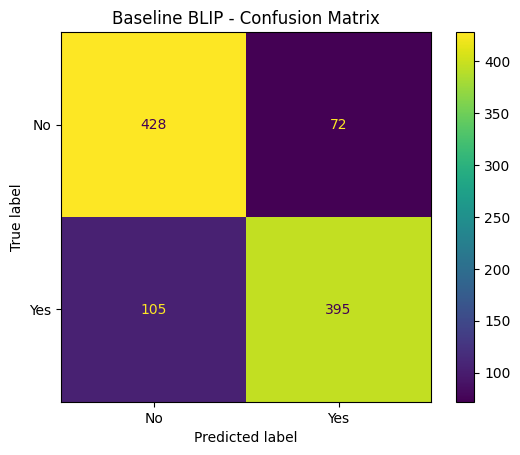

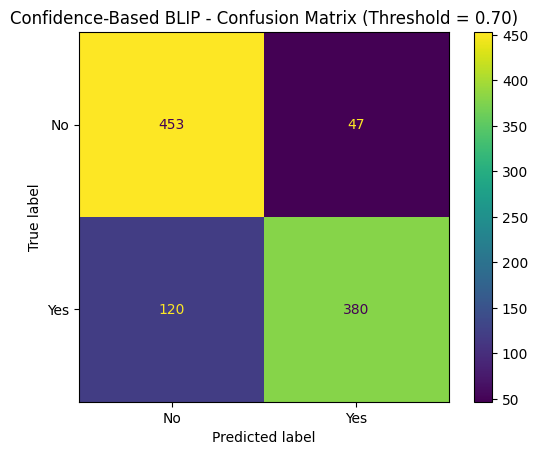

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Baseline predictions
baseline_cm = confusion_matrix(
    y_true,
    y_pred,
    labels=["no", "yes"]
)

# Confidence-based predictions at threshold 0.70
threshold = 0.70

confidence_predictions = [
    "yes" if p >= threshold else "no"
    for p in yes_probabilities
]

confidence_cm = confusion_matrix(
    true_labels_conf,
    confidence_predictions,
    labels=["no", "yes"]
)

# Print matrices
print("BASELINE CONFUSION MATRIX")
print(baseline_cm)

print("\nCONFIDENCE-BASED CONFUSION MATRIX (Threshold = 0.70)")
print(confidence_cm)


# Plot baseline
ConfusionMatrixDisplay(
    baseline_cm,
    display_labels=["No", "Yes"]
).plot()

plt.title("Baseline BLIP - Confusion Matrix")
plt.show()


# Plot confidence-based
ConfusionMatrixDisplay(
    confidence_cm,
    display_labels=["No", "Yes"]
).plot()

plt.title("Confidence-Based BLIP - Confusion Matrix (Threshold = 0.70)")
plt.show()

In [14]:
# Check the actual category values in our 1000 samples

from collections import Counter

category_counts = Counter(
    str(sample["category"]).strip().lower()
    for sample in test_data
)

print(category_counts)

Counter({'adversarial': 1000})


In [15]:
# ============================================
# CATEGORY-WISE POPE EVALUATION
# 300 samples per category
# ============================================

import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# --------------------------------------------
# Select 300 samples from each category
# --------------------------------------------

categories = ["random", "popular", "adversarial"]

category_data = {}

for category in categories:

    # Get all indices for this category
    category_indices = [
        i for i, sample in enumerate(pope["test"])
        if str(sample["category"]).strip().lower() == category
    ]

    # Take first 300
    selected_indices = category_indices[:300]

    category_data[category] = selected_indices

    print(
        category,
        "samples found:",
        len(category_indices),
        "| selected:",
        len(selected_indices)
    )


# --------------------------------------------
# Calculate confidence for each category
# --------------------------------------------

category_results = []

for category in categories:

    print(f"\nEvaluating {category.upper()}...")

    indices = category_data[category]

    category_true = []
    category_probs = []

    for idx in tqdm(indices):

        sample = pope["test"][idx]

        image = sample["image"]
        question = sample["question"]
        true_answer = sample["answer"].lower().strip()

        confidence_yes = get_yes_no_probability(
            image,
            question
        )

        category_true.append(true_answer)
        category_probs.append(confidence_yes)


    # ----------------------------------------
    # Threshold = 0.70
    # ----------------------------------------

    category_pred = [
        "yes" if p >= 0.70 else "no"
        for p in category_probs
    ]


    # ----------------------------------------
    # Metrics
    # ----------------------------------------

    accuracy = accuracy_score(
        category_true,
        category_pred
    )

    precision = precision_score(
        category_true,
        category_pred,
        pos_label="yes",
        zero_division=0
    )

    recall = recall_score(
        category_true,
        category_pred,
        pos_label="yes",
        zero_division=0
    )

    f1 = f1_score(
        category_true,
        category_pred,
        pos_label="yes",
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        category_true,
        category_pred,
        labels=["no", "yes"]
    ).ravel()

    fpr = fp / (fp + tn + 1e-8)

    yes_ratio = category_pred.count("yes") / len(category_pred)


    category_results.append({
        "Category": category,
        "Samples": len(indices),
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "FPR": fpr,
        "Yes Ratio": yes_ratio
    })


# --------------------------------------------
# Final table
# --------------------------------------------

category_df = pd.DataFrame(category_results)

print("\n========== CATEGORY-WISE RESULTS ==========\n")

display(
    category_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "FPR": "{:.4f}",
        "Yes Ratio": "{:.4f}"
    })
)

print("\n============================================")

random samples found: 3000 | selected: 300
popular samples found: 3000 | selected: 300
adversarial samples found: 3000 | selected: 300

Evaluating RANDOM...


  0%|          | 0/300 [00:00<?, ?it/s]


Evaluating POPULAR...


  0%|          | 0/300 [00:00<?, ?it/s]


Evaluating ADVERSARIAL...


  0%|          | 0/300 [00:00<?, ?it/s]


========== CATEGORY-WISE RESULTS ==========



,Category,Samples,Accuracy,Precision,Recall,F1,FPR,Yes Ratio
0,random,300,0.8667,0.9583,0.7667,0.8519,0.0333,0.4000
1,popular,300,0.8533,0.9274,0.7667,0.8394,0.0600,0.4133
2,adversarial,300,0.8300,0.8779,0.7667,0.8185,0.1067,0.4367


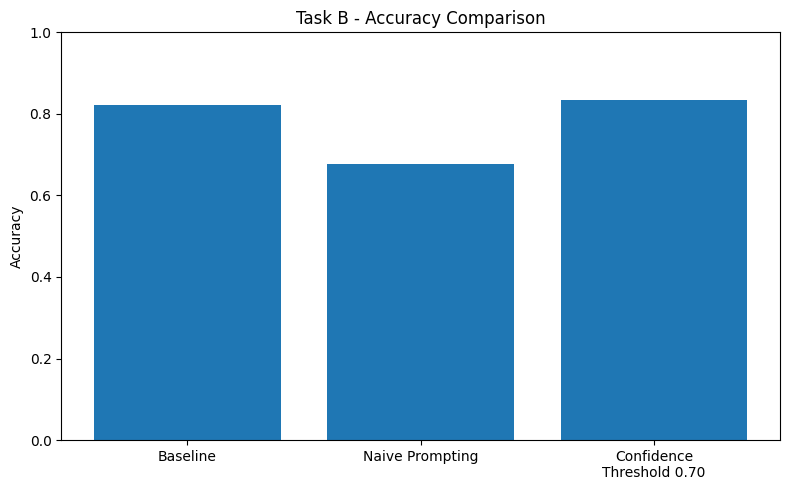

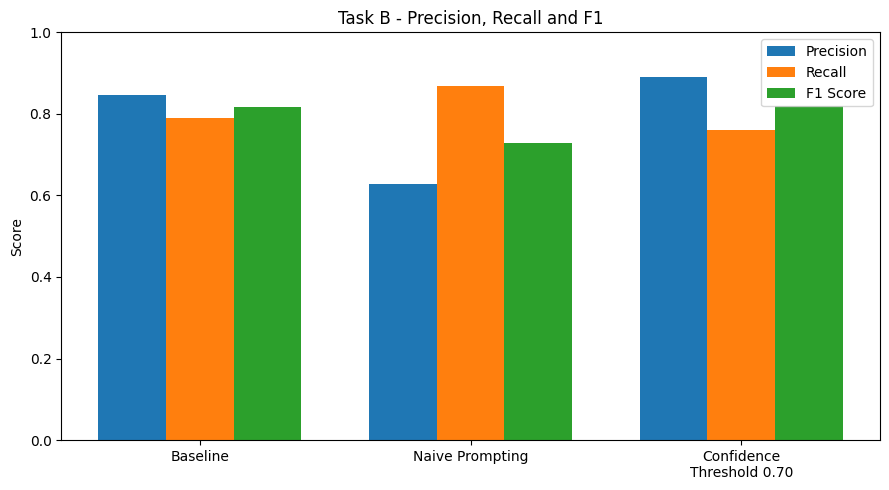

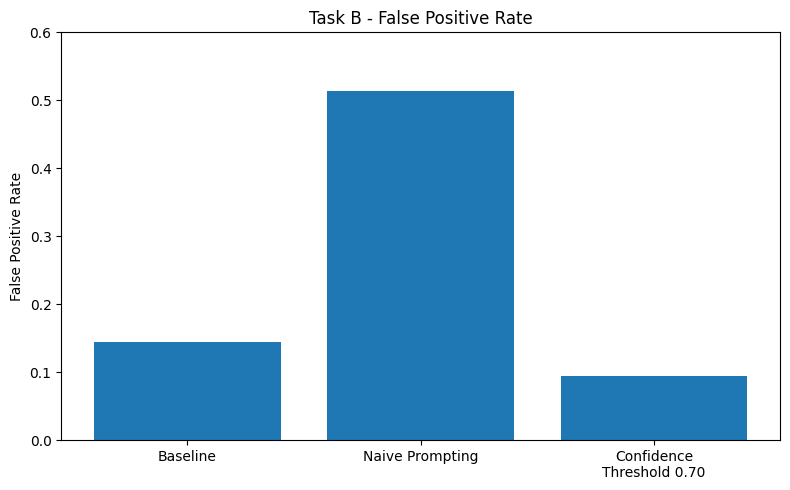

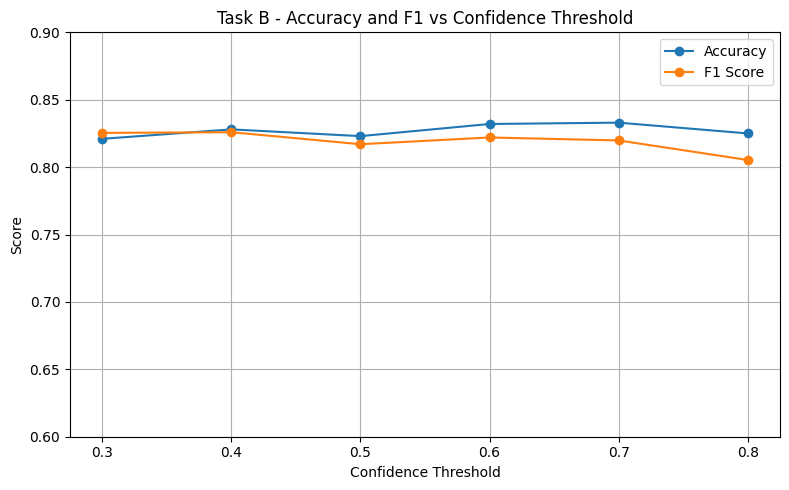

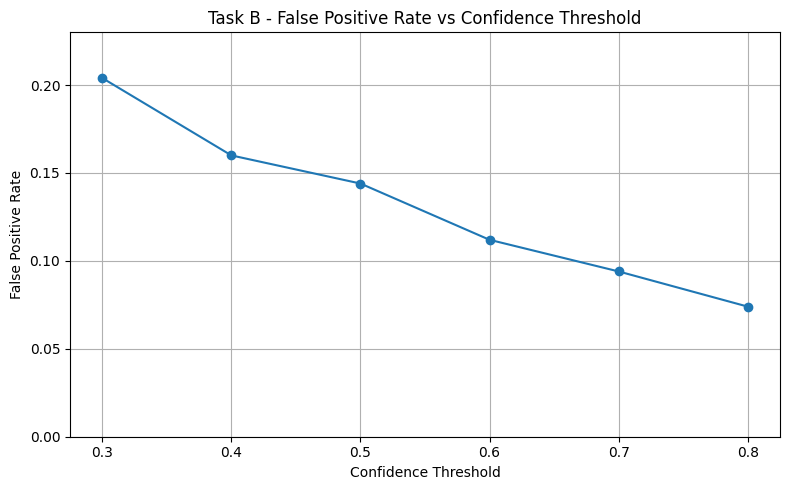

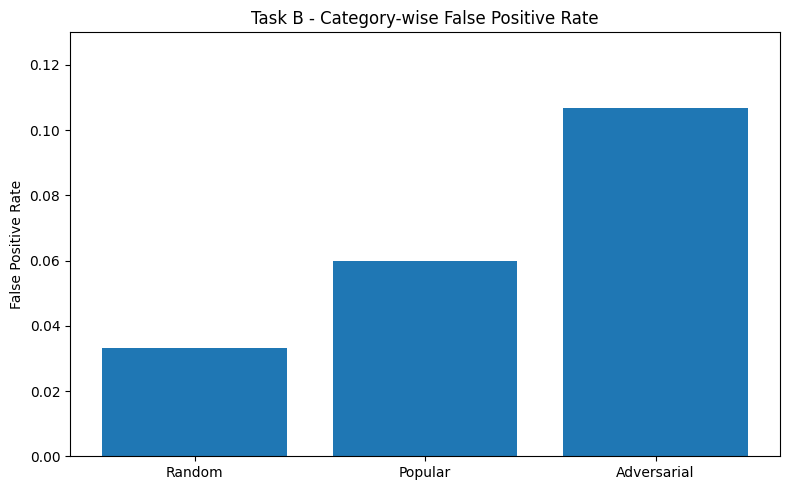

FINAL TASK B SUMMARY


,Method,Accuracy,Precision,Recall,F1 Score,FPR
0,Baseline,0.8230,0.8458,0.7900,0.8170,0.1440
1,Naive Prompting,0.6777,0.6290,0.8680,0.7294,0.5130
2,Confidence Threshold 0.70,0.8330,0.8899,0.7600,0.8198,0.0940


In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==========================================
# FINAL TASK B RESULTS
# ==========================================

methods = ["Baseline", "Naive Prompting", "Confidence\nThreshold 0.70"]

accuracy  = [0.8230, 0.6777, 0.8330]
precision = [0.8458, 0.6290, 0.8899]
recall    = [0.7900, 0.8680, 0.7600]
f1        = [0.8170, 0.7294, 0.8198]
fpr       = [0.1440, 0.5130, 0.0940]


# ------------------------------------------
# GRAPH 1: Accuracy
# ------------------------------------------

plt.figure(figsize=(8,5))
plt.bar(methods, accuracy)
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.title("Task B - Accuracy Comparison")
plt.tight_layout()
plt.show()


# ------------------------------------------
# GRAPH 2: Precision, Recall, F1
# ------------------------------------------

x = np.arange(3)
width = 0.25

plt.figure(figsize=(9,5))

plt.bar(x - width, precision, width, label="Precision")
plt.bar(x, recall, width, label="Recall")
plt.bar(x + width, f1, width, label="F1 Score")

plt.xticks(x, methods)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Task B - Precision, Recall and F1")
plt.legend()
plt.tight_layout()
plt.show()


# ------------------------------------------
# GRAPH 3: FALSE POSITIVE RATE
# Most important hallucination graph
# ------------------------------------------

plt.figure(figsize=(8,5))

plt.bar(methods, fpr)

plt.ylabel("False Positive Rate")
plt.ylim(0, 0.6)
plt.title("Task B - False Positive Rate")
plt.tight_layout()
plt.show()


# ------------------------------------------
# GRAPH 4: Threshold Analysis
# ------------------------------------------

thresholds = [0.30, 0.40, 0.50, 0.60, 0.70, 0.80]

threshold_accuracy = [
    0.821, 0.828, 0.823,
    0.832, 0.833, 0.825
]

threshold_f1 = [
    0.8254, 0.8259, 0.8170,
    0.8220, 0.8198, 0.8053
]

threshold_fpr = [
    0.204, 0.160, 0.144,
    0.112, 0.094, 0.074
]


plt.figure(figsize=(8,5))

plt.plot(
    thresholds,
    threshold_accuracy,
    marker="o",
    label="Accuracy"
)

plt.plot(
    thresholds,
    threshold_f1,
    marker="o",
    label="F1 Score"
)

plt.xlabel("Confidence Threshold")
plt.ylabel("Score")
plt.ylim(0.6, 0.9)
plt.title("Task B - Accuracy and F1 vs Confidence Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------
# GRAPH 5: FPR vs Threshold
# ------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(
    thresholds,
    threshold_fpr,
    marker="o"
)

plt.xlabel("Confidence Threshold")
plt.ylabel("False Positive Rate")
plt.ylim(0, 0.23)
plt.title("Task B - False Positive Rate vs Confidence Threshold")
plt.grid(True)
plt.tight_layout()
plt.show()


# ------------------------------------------
# GRAPH 6: Category-wise FPR
# ------------------------------------------

categories = [
    "Random",
    "Popular",
    "Adversarial"
]

category_fpr = [
    0.0333,
    0.0600,
    0.1067
]

plt.figure(figsize=(8,5))

plt.bar(categories, category_fpr)

plt.ylabel("False Positive Rate")
plt.ylim(0, 0.13)
plt.title("Task B - Category-wise False Positive Rate")
plt.tight_layout()
plt.show()


# ------------------------------------------
# FINAL SUMMARY TABLE
# ------------------------------------------

summary = pd.DataFrame({
    "Method": methods,
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "FPR": fpr
})

print("FINAL TASK B SUMMARY")

display(
    summary.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "FPR": "{:.4f}"
    })
)